# Flow-Cast Data Pipeline
This notebook demonstrates the end-to-end automated ETL pipeline.

### Pipeline Stages:
1. **Ingest & Validate**: Loads raw data and ensures schemas match expectations.
2. **Normalize**: Standardizes timestamps and strictly enforces 30-minute intervals.
3. **Clean & Interpolate**: Removes outliers, caps impossible values, and interpolates missing gaps.
4. **Merge & Harmonize**: Left-joins weather and calendar data, extracts JSON features, and comprehensively fills missing values.
5. **Validate & Export**: Asserts data quality (no nulls, valid bounds) before saving to CSV.

In [19]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
import sys
import os
import pandas as pd
import importlib

# Add the src directory to the python path so we can import from it
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

import clean
importlib.reload(clean)

<module 'clean' from 'c:\\Users\\ojasd\\projects\\Flow-Cast\\src\\clean.py'>

In [21]:
# Run the full end-to-end pipeline
clean.process_data()

Loading datasets...
Validating raw data schemas...
Standardizing temporal fields...
Cleaning sensor data...
Cleaning weather data...
Aligning and Merging datasets...
Expanding vehicle_type_dist JSON...
Handling comprehensive missing values and harmonizing categories...
Running Data Quality Validation...
Running Data Quality Checks...
Data quality checks passed successfully!
Saving processed dataset to c:\Users\ojasd\projects\Flow-Cast\data\interim\processed_dataset.csv...
Data processing complete. Final shape: (176701, 28)


## Exploratory Data Analysis
The dataset is now completely cleaned, validated, and ready for EDA.

In [22]:
data_path = os.path.join('..', 'data', 'interim', 'processed_dataset.csv')
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"Processed dataset shape: {df.shape}")
    display(df.head())
else:
    print("Processed dataset was not found.")

Processed dataset shape: (176701, 28)


,road_id,road_name,latitude,longitude,weather_station_id,traffic_volume,vehicle_count,avg_speed,occupancy,congestion_level,...,visibility,public_holiday,holiday_name,event_flag,event_name,roadwork_flag,2W,Car,LCV,HCV
0,NL-001,Northline Ave @ 5th,28.643422,77.190411,WS-NORTH,97.0,97,53.0,7.7,Free-flow,...,10000.0,1,New Year's Day,0,No Event,0,0.39,0.35,0.12,0.14
1,NL-001,Northline Ave @ 5th,28.643422,77.190411,WS-NORTH,99.0,99,56.7,6.8,Unknown,...,10000.0,1,New Year's Day,0,No Event,0,0.44,0.34,0.11,0.12
2,NL-001,Northline Ave @ 5th,28.643422,77.190411,WS-NORTH,102.0,102,55.7,7.6,Free-flow,...,10000.0,1,New Year's Day,0,No Event,0,0.44,0.43,0.06,0.07
3,NL-001,Northline Ave @ 5th,28.643422,77.190411,WS-NORTH,113.0,113,53.5,7.6,Free-flow,...,10000.0,1,New Year's Day,0,No Event,0,0.43,0.36,0.09,0.13
4,NL-001,Northline Ave @ 5th,28.643422,77.190411,WS-NORTH,92.0,92,53.9,7.2,Free-flow,...,10000.0,1,New Year's Day,0,No Event,0,0.42,0.39,0.09,0.10


In [23]:
# Verify that all nulls have been properly handled by the pipeline
df.isna().sum()

road_id               0
road_name             0
latitude              0
longitude             0
weather_station_id    0
traffic_volume        0
vehicle_count         0
avg_speed             0
occupancy             0
congestion_level      0
travel_time           0
accident_count        0
signal_timing         0
road_capacity         0
timestamp             0
weather_condition     0
temperature           0
rainfall              0
visibility            0
public_holiday        0
holiday_name          0
event_flag            0
event_name            0
roadwork_flag         0
2W                    0
Car                   0
LCV                   0
HCV                   0
dtype: int64

In [24]:
df.dtypes

road_id                   str
road_name                 str
latitude              float64
longitude             float64
weather_station_id        str
traffic_volume        float64
vehicle_count           int64
avg_speed             float64
occupancy             float64
congestion_level          str
travel_time           float64
accident_count          int64
signal_timing           int64
road_capacity           int64
timestamp                 str
weather_condition         str
temperature           float64
rainfall              float64
visibility            float64
public_holiday          int64
holiday_name              str
event_flag              int64
event_name                str
roadwork_flag           int64
2W                    float64
Car                   float64
LCV                   float64
HCV                   float64
dtype: object

## Feature Engineering
Applying the feature engineering logic interactively.

In [37]:
import features
import importlib
importlib.reload(features)

df_featured = features.engineer_features(df.copy())
print(f"Dataset shape after feature engineering: {df_featured.shape}")
display(df_featured.head())

Engineering features...
Dataset shape after feature engineering: (176701, 54)


,road_id,road_name,latitude,longitude,weather_station_id,traffic_volume,vehicle_count,avg_speed,occupancy,congestion_level,...,volume_lag_48,speed_lag_48,traffic_volume_rolling_mean_4,traffic_volume_rolling_std_4,avg_speed_rolling_mean_4,avg_speed_rolling_std_4,traffic_volume_rolling_mean_8,traffic_volume_rolling_std_8,avg_speed_rolling_mean_8,avg_speed_rolling_std_8
0,NL-001,Northline Ave @ 5th,28.643422,77.190411,WS-NORTH,97.0,97,53.0,7.7,1,...,NaN,NaN,97.000000,NaN,53.000000,NaN,97.000000,NaN,53.000000,NaN
1,NL-001,Northline Ave @ 5th,28.643422,77.190411,WS-NORTH,99.0,99,56.7,6.8,0,...,NaN,NaN,98.000000,1.414214,54.850000,2.616295,98.000000,1.414214,54.850000,2.616295
2,NL-001,Northline Ave @ 5th,28.643422,77.190411,WS-NORTH,102.0,102,55.7,7.6,1,...,NaN,NaN,99.333333,2.516611,55.133333,1.913984,99.333333,2.516611,55.133333,1.913984
3,NL-001,Northline Ave @ 5th,28.643422,77.190411,WS-NORTH,113.0,113,53.5,7.6,1,...,NaN,NaN,102.750000,7.135592,54.725000,1.763283,102.750000,7.135592,54.725000,1.763283
4,NL-001,Northline Ave @ 5th,28.643422,77.190411,WS-NORTH,92.0,92,53.9,7.2,1,...,NaN,NaN,101.500000,8.736895,54.950000,1.508863,100.600000,7.829432,54.560000,1.570987


### Removing Missing Values From the Dataset 

In [38]:
df_featured=features.missing_values_features(df_featured)

Removing missing values...


### Inferences from Engineered Features

| Feature | Type | Inference |
|---|---|---|
| `congestion_level` (encoded) | Ordinal | Maps categorical severity (free-flow→severe) to integers 0–4. Enables ordinal regression & ranking models. |
| `weather_*` (one-hot) | Binary flags | Each weather type becomes a separate binary column, removing implicit ordinal assumptions across weather categories. |
| `hour` | Cyclic temporal | Captures intra-day rush-hour peaks (typically 8–10am and 5–7pm). Strong expected correlation with traffic volume. |
| `day_of_week` | Cyclic temporal | Distinguishes weekday vs. weekend travel patterns. Mondays and Fridays typically show distinct flows. |
| `is_weekend` | Binary flag | A direct boolean aggregation of `day_of_week`. Weekends generally see lower commercial traffic but higher recreational travel. |
| `volume_capacity_ratio` | Continuous ratio | Measures how saturated a road segment is. Values near or above 1.0 indicate severe congestion and degraded speed. |
| `is_raining` | Binary flag | Rain directly reduces speed and increases congestion. Expected negative correlation with `avg_speed`. |
| `low_visibility` | Binary flag | Visibility < 1000m forces slower speeds and increases accident risk. |
| `is_holiday` | Binary flag | Holidays reduce commuter traffic but may spike leisure travel on certain routes. |
| `volume_lag_1`, `volume_lag_2` | Lag features | Short-term traffic memory — previous 30-min and 60-min volume. High autocorrelation expected. |
| `volume_lag_48` | Lag feature | 24-hour lag (48 × 30 min). Captures same-time-yesterday pattern, which is very predictive for recurrent congestion. |
| `speed_lag_1`, `speed_lag_2`, `speed_lag_48` | Lag features | Same rationale as volume lags — speed autocorrelation over short and 24-hour horizons. |
| `traffic_volume_rolling_mean_4/8` | Rolling statistics | Smoothed volume over the last 2–4 hours. Reduces noise and captures trending up/down behaviour. |
| `traffic_volume_rolling_std_4/8` | Rolling statistics | Variance of volume over recent windows. High std indicates instability or incident-driven fluctuations. |
| `avg_speed_rolling_mean_4/8` | Rolling statistics | Trend in speed. A declining rolling mean flags an approaching congestion wave. |
| `avg_speed_rolling_std_4/8` | Rolling statistics | Speed variability — high std often accompanies stop-and-go traffic or accident zones. |

## Correlation Analysis
Analyzing relationships between non-target and target variables.
- **Regression Targets**: `traffic_volume`, `travel_time`
- **Classification Targets**: `congestion_level`, `accident_count` (proxy for risk)

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Get numeric columns from the feature-engineered dataframe
numeric_cols = df_featured.select_dtypes(include=['float64', 'int64', 'int32']).columns.tolist()
corr_matrix = df_featured[numeric_cols].corr()
print(f"Numeric columns available: {len(numeric_cols)}")

Numeric columns available: 42


### Regression Target Correlations
Pearson correlation of all numeric features against the two **regression targets**: `traffic_volume` and `travel_time`.

> **Interpretation guide**: Values close to +1 indicate strong positive correlation; close to –1 indicate strong negative correlation. Features with |r| > 0.3 are typically useful predictors.

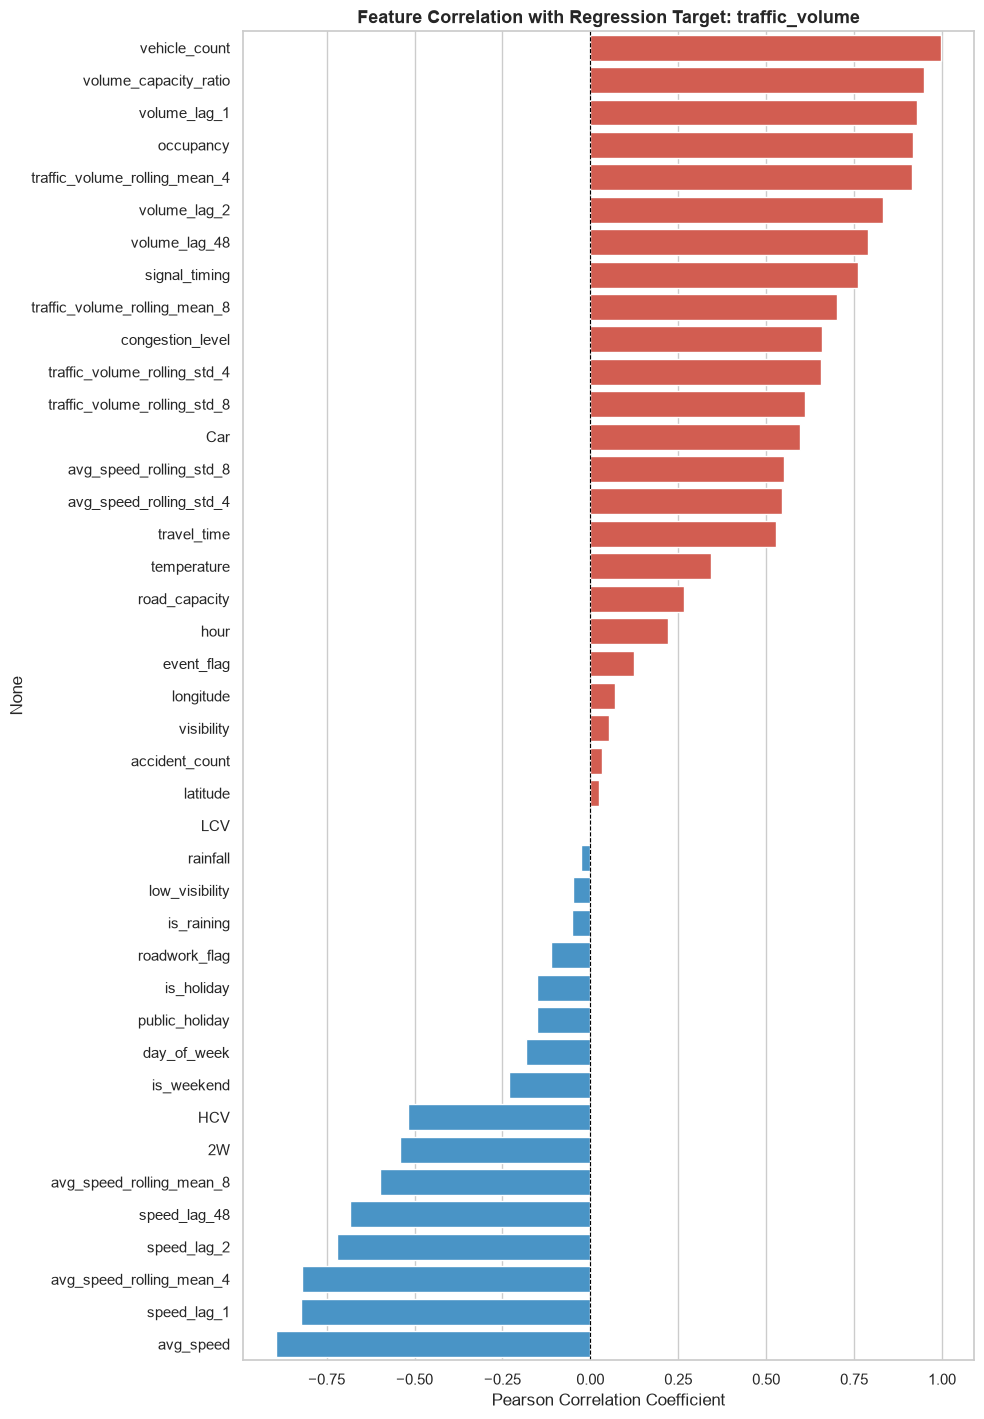

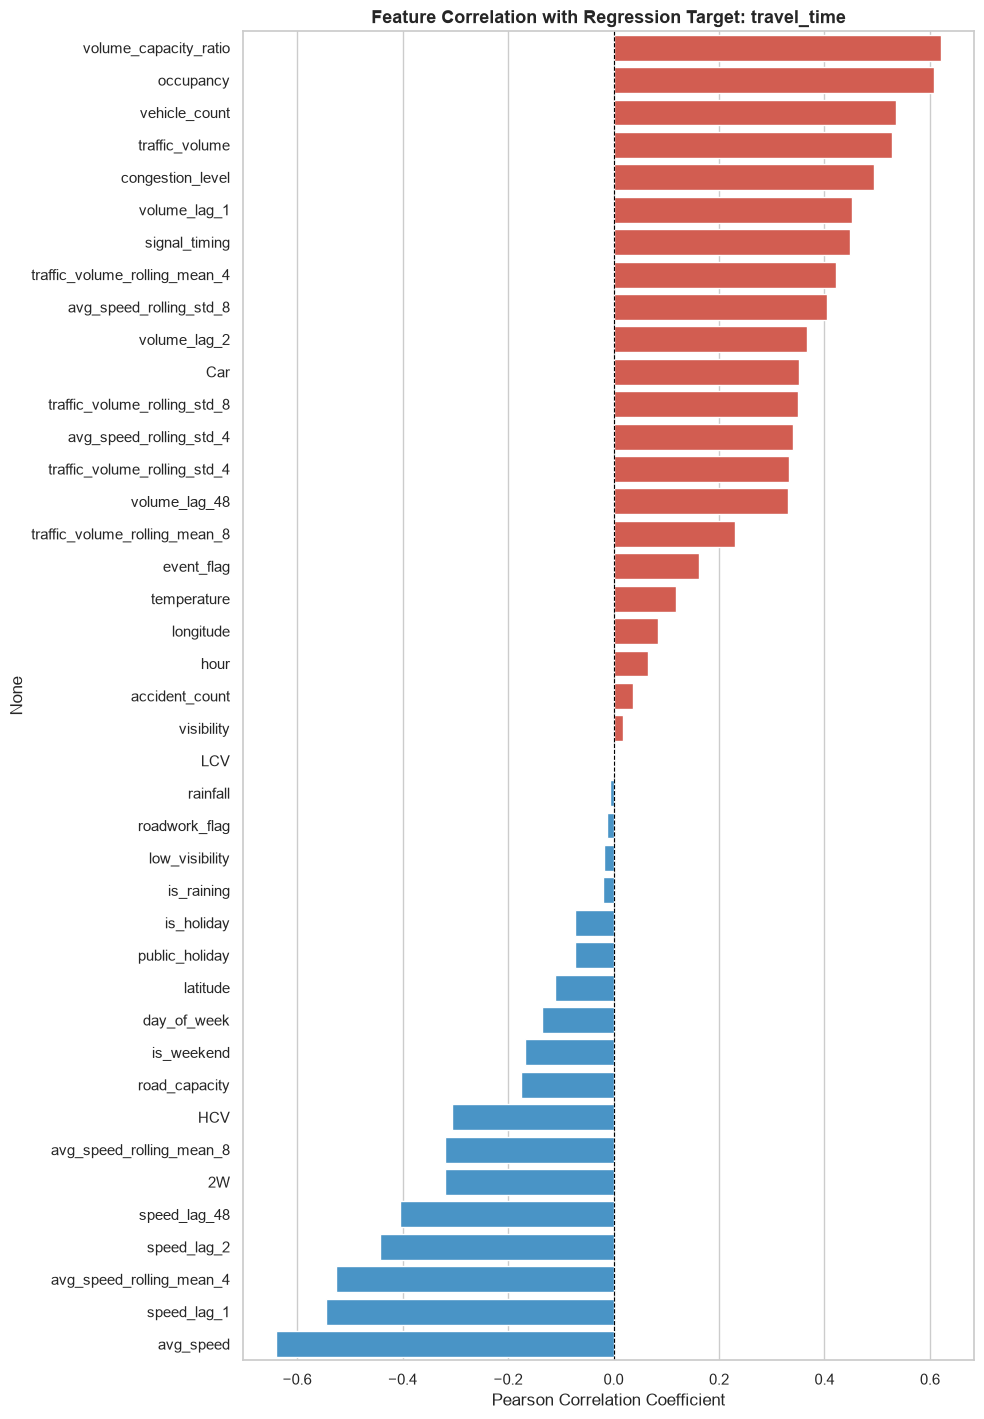

In [40]:
reg_targets = ['traffic_volume', 'travel_time']
valid_reg = [t for t in reg_targets if t in corr_matrix.columns]

for target in valid_reg:
    target_corr = corr_matrix[target].drop(target).sort_values(ascending=False)
    plt.figure(figsize=(10, max(6, len(target_corr) * 0.35)))
    colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
    sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)
    plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
    plt.title(f'Feature Correlation with Regression Target: {target}', fontsize=13, fontweight='bold')
    plt.xlabel('Pearson Correlation Coefficient')
    plt.tight_layout()
    plt.show()

### Classification Target Correlations
Pearson correlation of all numeric features against the two **classification proxy targets**: `congestion_level` (ordinal severity) and `accident_count` (binary risk proxy).

> **Note**: Pearson correlation is used here as a fast screening metric. For a true ordinal target like `congestion_level`, Spearman rank correlation may be more appropriate in subsequent analysis.

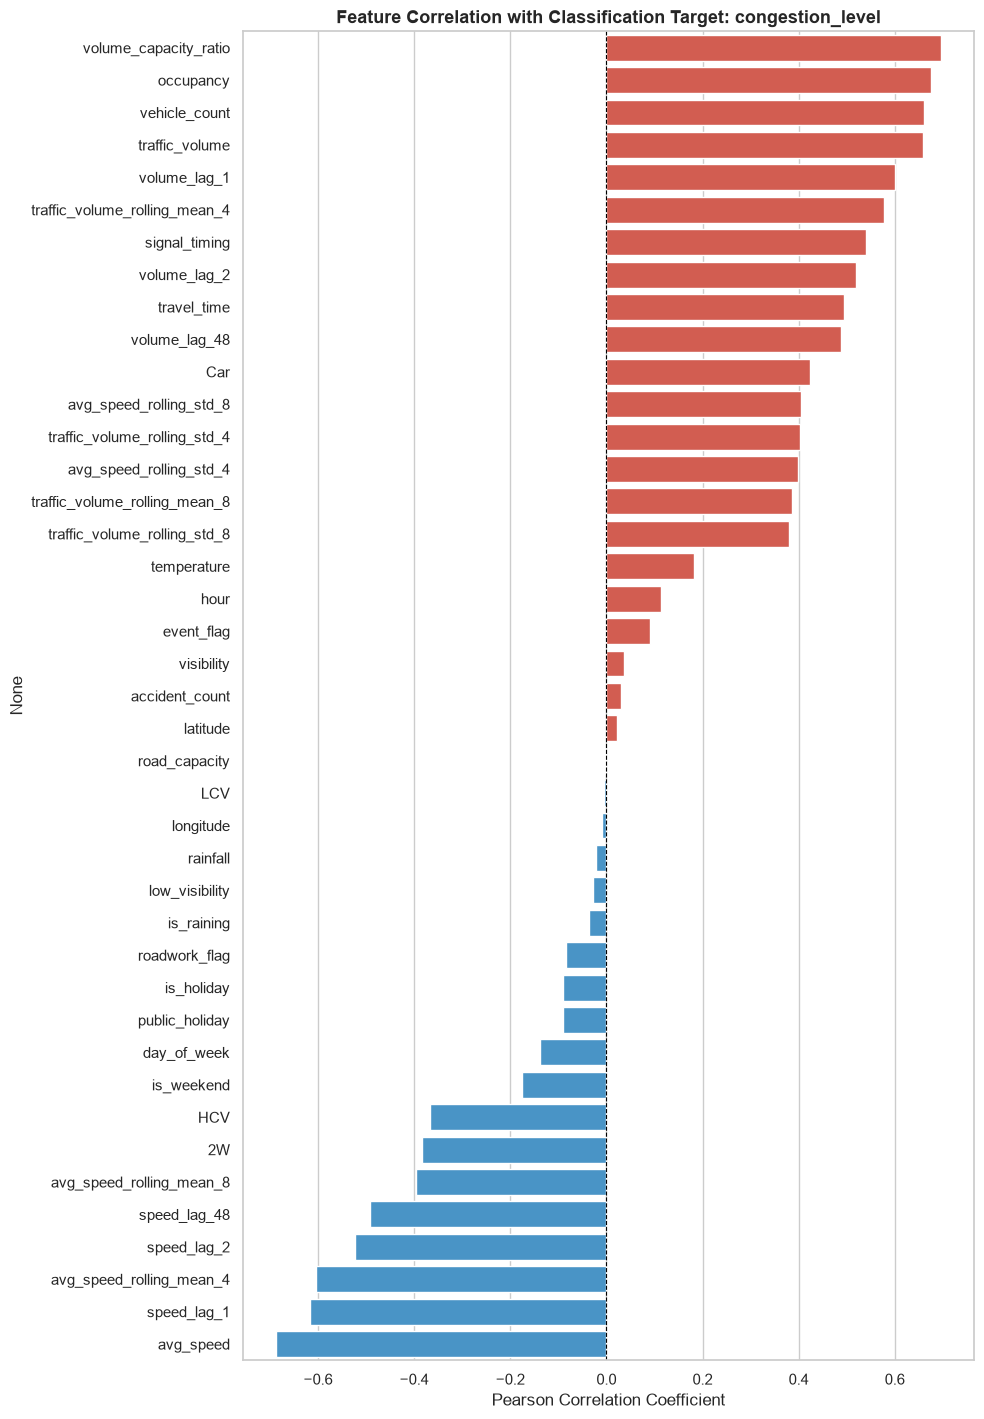

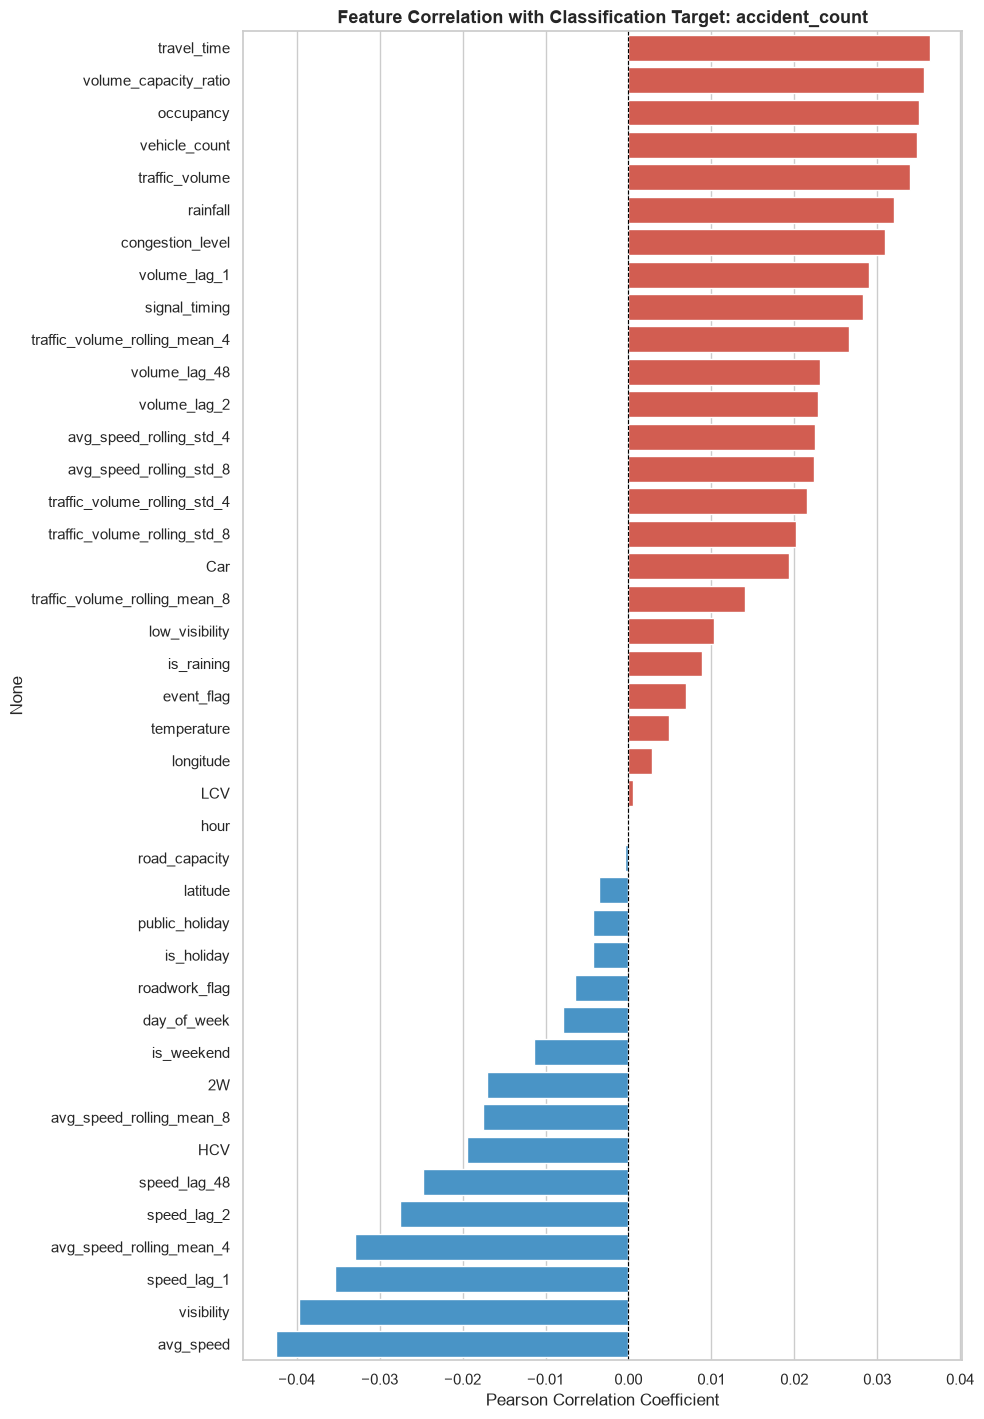

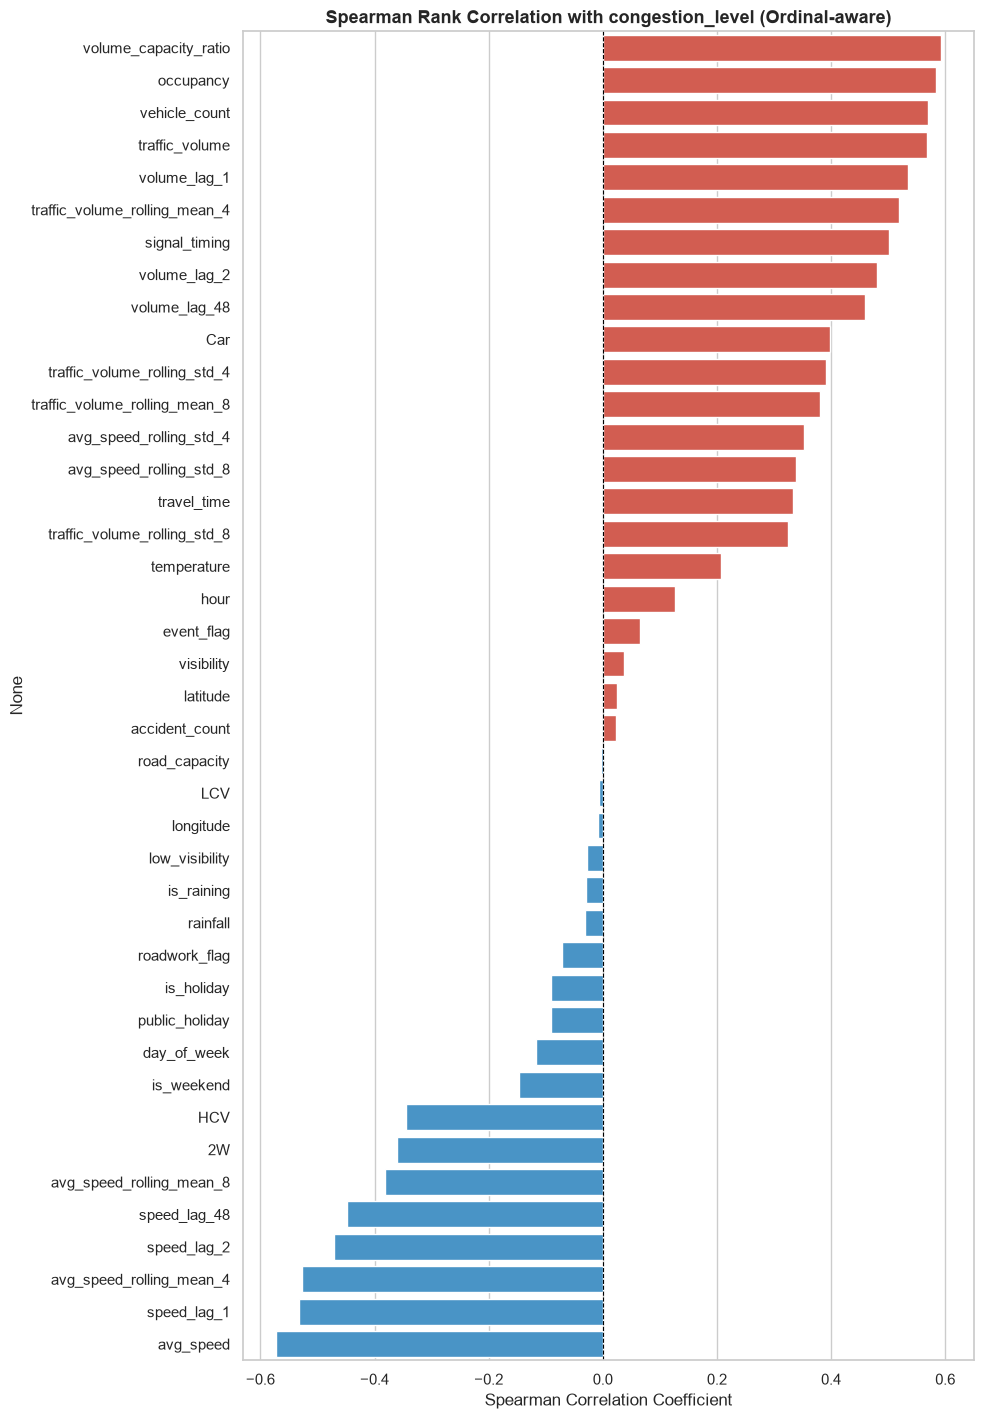

In [41]:
class_targets = ['congestion_level', 'accident_count']
valid_class = [t for t in class_targets if t in corr_matrix.columns]

for target in valid_class:
    target_corr = corr_matrix[target].drop(target).sort_values(ascending=False)
    plt.figure(figsize=(10, max(6, len(target_corr) * 0.35)))
    colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
    sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)
    plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
    plt.title(f'Feature Correlation with Classification Target: {target}', fontsize=13, fontweight='bold')
    plt.xlabel('Pearson Correlation Coefficient')
    plt.tight_layout()
    plt.show()

# Also show Spearman correlation for ordinal congestion_level
if 'congestion_level' in df_featured.columns:
    spearman_corr = df_featured[numeric_cols].corr(method='spearman')['congestion_level'].drop('congestion_level').sort_values(ascending=False)
    plt.figure(figsize=(10, max(6, len(spearman_corr) * 0.35)))
    colors = ['#e74c3c' if v > 0 else '#3498db' for v in spearman_corr.values]
    sns.barplot(x=spearman_corr.values, y=spearman_corr.index, palette=colors)
    plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
    plt.title('Spearman Rank Correlation with congestion_level (Ordinal-aware)', fontsize=13, fontweight='bold')
    plt.xlabel('Spearman Correlation Coefficient')
    plt.tight_layout()
    plt.show()

In [42]:
df_featured.isna().sum()

road_id                          0
road_name                        0
latitude                         0
longitude                        0
weather_station_id               0
traffic_volume                   0
vehicle_count                    0
avg_speed                        0
occupancy                        0
congestion_level                 0
travel_time                      0
accident_count                   0
signal_timing                    0
road_capacity                    0
timestamp                        0
temperature                      0
rainfall                         0
visibility                       0
public_holiday                   0
holiday_name                     0
event_flag                       0
event_name                       0
roadwork_flag                    0
2W                               0
Car                              0
LCV                              0
HCV                              0
weather_clear                    0
weather_cloudy      

In [43]:
df_featured.columns

Index(['road_id', 'road_name', 'latitude', 'longitude', 'weather_station_id',
       'traffic_volume', 'vehicle_count', 'avg_speed', 'occupancy',
       'congestion_level', 'travel_time', 'accident_count', 'signal_timing',
       'road_capacity', 'timestamp', 'temperature', 'rainfall', 'visibility',
       'public_holiday', 'holiday_name', 'event_flag', 'event_name',
       'roadwork_flag', '2W', 'Car', 'LCV', 'HCV', 'weather_clear',
       'weather_cloudy', 'weather_fog', 'weather_overcast', 'weather_rain',
       'weather_unknown', 'hour', 'day_of_week', 'is_weekend',
       'volume_capacity_ratio', 'is_raining', 'low_visibility', 'is_holiday',
       'volume_lag_1', 'speed_lag_1', 'volume_lag_2', 'speed_lag_2',
       'volume_lag_48', 'speed_lag_48', 'traffic_volume_rolling_mean_4',
       'traffic_volume_rolling_std_4', 'avg_speed_rolling_mean_4',
       'avg_speed_rolling_std_4', 'traffic_volume_rolling_mean_8',
       'traffic_volume_rolling_std_8', 'avg_speed_rolling_mean_8',
  